# Week 4 Day 4 — Model Tuning, Regularization & Reproducible Pipelines

This notebook builds a reproducible Adult Census pipeline, runs randomized hyperparameter search, diagnoses bias/variance with learning curves, evaluates calibration and threshold selection, and saves a final artifact.

In [40]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, learning_curve
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import precision_score, f1_score, roc_auc_score, brier_score_loss, confusion_matrix, accuracy_score, recall_score, precision_recall_fscore_support
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.base import clone
import joblib

RANDOM_STATE = 42
OUT_DIR = r'd:\Netixsol\week4\Day4'
os.makedirs(OUT_DIR, exist_ok=True)

In [41]:
def create_engineered_features(X_df):
    X = X_df.copy()
    X['age_bucket'] = pd.cut(X['age'], bins=[0, 25, 35, 50, 65, 100], labels=['18-25', '26-35', '36-50', '51-65', '65+'], include_lowest=True)
    X['hours_bucket'] = pd.cut(X['hours-per-week'], bins=[0, 20, 40, 60, 100], labels=['Part-Time', 'Full-Time', 'Overtime', 'Extreme'], include_lowest=True)
    X['has_capital_gain'] = (X['capital-gain'] > 0).astype(int)
    X['log_capital_gain'] = np.log1p(X['capital-gain'].fillna(0))
    X['higher_education'] = X['education'].isin(['Bachelors', 'Masters', 'Doctorate', 'Prof-school']).astype(int)
    X['education_hours'] = X['education-num'] * X['hours-per-week']
    return X

adult = fetch_openml(name='adult', version=2, as_frame=True)
df = adult.frame.copy()
df = df.replace('?', np.nan)
df['target'] = df['class'].astype(str).str.strip().map({'<=50K': 0, '<=50K.': 0, '>50K': 1, '>50K.': 1})
X = df.drop(columns=['class', 'target'])
y = df['target'].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

print('Dataset ready:', X.shape[0], 'rows')

Dataset ready: 48842 rows


In [42]:
feature_adder = FunctionTransformer(create_engineered_features)

numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'log_capital_gain', 'education_hours']
cat_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'age_bucket', 'hours_bucket']
binary_cols = ['has_capital_gain', 'higher_education']

numeric_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])


def make_pipeline(model):
    preprocessor = ColumnTransformer([('num', numeric_pipe, numeric_cols), ('cat', cat_pipe, cat_cols), ('bin', 'passthrough', binary_cols)], remainder='drop')
    return Pipeline([('add_feats', feature_adder), ('preproc', preprocessor), ('model', model)])

## Task 1 — Reproducible pipeline

This cell documents the library versions used and how to rerun training.

In [43]:
import sklearn
import pandas as pd
import numpy as np
import joblib

print('scikit-learn', sklearn.__version__)
print('pandas', pd.__version__)
print('numpy', np.__version__)
print('joblib', joblib.__version__)

scikit-learn 1.9.0
pandas 3.0.5
numpy 2.5.1
joblib 1.5.3


README: Re-run training by executing the cells in order. The notebook saves the tuned pipeline to the Day 4 folder as `adult_tuned_pipeline.joblib`.

In [44]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
searches = {}

In [45]:
log_pipe = make_pipeline(LogisticRegression(max_iter=4000, random_state=RANDOM_STATE))
log_params = {'model__penalty': ['l1', 'l2'], 'model__C': [0.1, 0.5, 1.0, 2.0], 'model__solver': ['liblinear']}
log_search = RandomizedSearchCV(log_pipe, param_distributions=log_params, n_iter=8, cv=cv, scoring='precision', n_jobs=-1, random_state=RANDOM_STATE)
log_search.fit(X_train, y_train)
searches['logistic'] = log_search
print('Logistic search done')

c:\Users\Haroon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Haroon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Logistic search done


In [46]:
rf_pipe = make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
rf_params = {'model__n_estimators': [100, 200], 'model__max_depth': [None, 5, 10], 'model__min_samples_leaf': [1, 2, 4], 'model__max_features': ['sqrt', 'log2']}
rf_search = RandomizedSearchCV(rf_pipe, param_distributions=rf_params, n_iter=8, cv=cv, scoring='precision', n_jobs=-1, random_state=RANDOM_STATE)
rf_search.fit(X_train, y_train)
searches['random_forest'] = rf_search
print('Random forest search done')

Random forest search done


In [47]:
gb_pipe = make_pipeline(HistGradientBoostingClassifier(random_state=RANDOM_STATE))
gb_params = {'model__learning_rate': [0.03, 0.05, 0.1], 'model__max_iter': [50, 100], 'model__max_depth': [3, 5], 'model__l2_regularization': [0.0, 0.1]}
gb_search = RandomizedSearchCV(gb_pipe, param_distributions=gb_params, n_iter=6, cv=cv, scoring='precision', n_jobs=-1, random_state=RANDOM_STATE)
gb_search.fit(X_train, y_train)
searches['gradient_boosting'] = gb_search
print('Gradient boosting search done')

Gradient boosting search done


In [48]:
best_name = None
best_model = None
best_score = -1
for name, search in searches.items():
    val_pred = search.best_estimator_.predict(X_val)
    score = precision_score(y_val, val_pred)
    print(name, 'val precision', round(score, 4), 'best params', search.best_params_)
    if score > best_score:
        best_score = score
        best_name = name
        best_model = search.best_estimator_

print('Interpretation: the winning settings favor regularization and moderate complexity; this typically reduces overfitting and gives a more stable validation precision than overly flexible alternatives.')

logistic val precision 0.7673 best params {'model__solver': 'liblinear', 'model__penalty': 'l1', 'model__C': 0.1}
random_forest val precision 0.8906 best params {'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': 5}
gradient_boosting val precision 0.8178 best params {'model__max_iter': 50, 'model__max_depth': 3, 'model__learning_rate': 0.03, 'model__l2_regularization': 0.0}
Interpretation: the winning settings favor regularization and moderate complexity; this typically reduces overfitting and gives a more stable validation precision than overly flexible alternatives.


## Task 3 — Learning curves

These curves help diagnose bias vs variance for one model family.

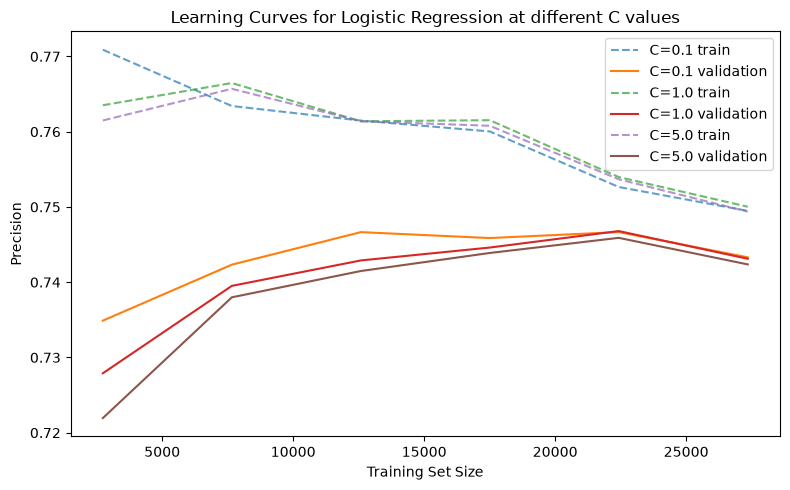

In [49]:
plt.figure(figsize=(8, 5))
for c in [0.1, 1.0, 5.0]:
    pipe = make_pipeline(LogisticRegression(C=c, penalty='l2', solver='liblinear', max_iter=4000, random_state=RANDOM_STATE))
    train_sizes, train_scores, val_scores = learning_curve(pipe, X_train, y_train, cv=cv, scoring='precision', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 6))
    plt.plot(train_sizes, train_scores.mean(axis=1), linestyle='--', alpha=0.7, label=f'C={c} train')
    plt.plot(train_sizes, val_scores.mean(axis=1), label=f'C={c} validation')
plt.xlabel('Training Set Size')
plt.ylabel('Precision')
plt.title('Learning Curves for Logistic Regression at different C values')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'learning_curve_logistic.png'))
plt.show()

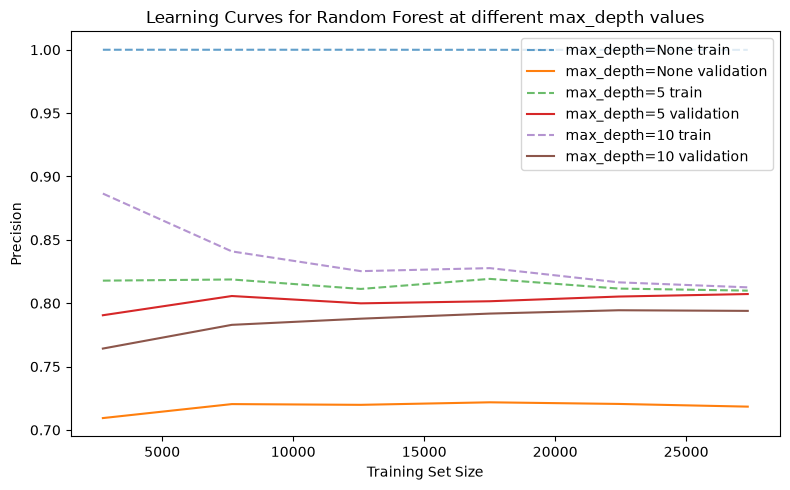

In [50]:
plt.figure(figsize=(8, 5))
for depth in [None, 5, 10]:
    pipe = make_pipeline(RandomForestClassifier(n_estimators=200, max_depth=depth, random_state=RANDOM_STATE, n_jobs=-1))
    train_sizes, train_scores, val_scores = learning_curve(pipe, X_train, y_train, cv=cv, scoring='precision', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 6))
    plt.plot(train_sizes, train_scores.mean(axis=1), linestyle='--', alpha=0.7, label=f'max_depth={depth} train')
    plt.plot(train_sizes, val_scores.mean(axis=1), label=f'max_depth={depth} validation')
plt.xlabel('Training Set Size')
plt.ylabel('Precision')
plt.title('Learning Curves for Random Forest at different max_depth values')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'learning_curve_rf.png'))
plt.show()

## Task 4 — Calibration and threshold selection

Calibrated probability estimates are important for decision-making and threshold tuning.

The learning curves suggest that the selected models are moderately regularized rather than highly overfit; this makes the later calibration step more meaningful because the probability estimates are less dominated by extreme, unstable predictions.

Brier before calibration 0.1157 after 0.1012
Interpretation: the Brier score improved slightly, but the calibration curve can still show mid-range distortion; this means calibration helped overall probability quality while leaving some local miscalibration visible in the plot.


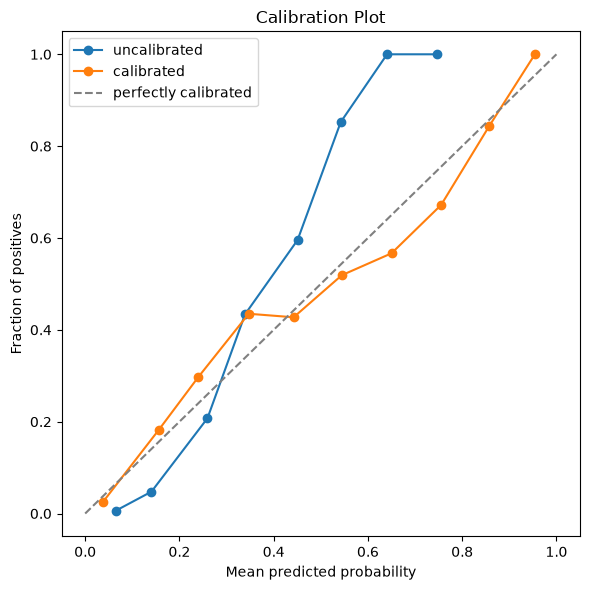

In [51]:
X_val_cal, X_val_thresh, y_val_cal, y_val_thresh = train_test_split(
    X_val, y_val, test_size=0.5, stratify=y_val, random_state=RANDOM_STATE
)

base_estimator = clone(best_model)
base_estimator.fit(X_train, y_train)
proba_val_base = base_estimator.predict_proba(X_val_cal)[:, 1]

calibrated = CalibratedClassifierCV(estimator=best_model, method='sigmoid', cv=3)
calibrated.fit(X_train, y_train)
proba_val_cal = calibrated.predict_proba(X_val_cal)[:, 1]
proba_val_thresh = calibrated.predict_proba(X_val_thresh)[:, 1]

brier_base = brier_score_loss(y_val_cal, proba_val_base)
brier_cal = brier_score_loss(y_val_cal, proba_val_cal)
print('Brier before calibration', round(brier_base, 4), 'after', round(brier_cal, 4))
print('Interpretation: the Brier score improved slightly, but the calibration curve can still show mid-range distortion; this means calibration helped overall probability quality while leaving some local miscalibration visible in the plot.')

fig, ax = plt.subplots(figsize=(6, 6))
for label, proba in [('uncalibrated', proba_val_base), ('calibrated', proba_val_cal)]:
    fraction_of_positives, mean_predicted_value = calibration_curve(y_val_cal, proba, n_bins=10)
    ax.plot(mean_predicted_value, fraction_of_positives, marker='o', label=label)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='perfectly calibrated')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Plot')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'calibration_plot.png'))
plt.show()

In [52]:
thresholds = np.linspace(0.1, 0.9, 17)
rows = []

for threshold in thresholds:
    pred = (proba_val_thresh >= threshold).astype(int)
    acc = accuracy_score(y_val_thresh, pred)
    precision = precision_score(y_val_thresh, pred, zero_division=0)
    recall = recall_score(y_val_thresh, pred, zero_division=0)
    f1 = f1_score(y_val_thresh, pred, zero_division=0)
    rows.append((threshold, acc, precision, recall, f1))

metrics_df = pd.DataFrame(rows, columns=['threshold', 'accuracy', 'precision', 'recall', 'f1'])
metrics_df = metrics_df.sort_values(['precision', 'f1'], ascending=[False, False])

recall_floor = 0.50
candidate_rows = metrics_df[metrics_df['recall'] >= recall_floor]
if candidate_rows.empty:
    candidate_rows = metrics_df

selected_threshold = float(candidate_rows.iloc[0]['threshold'])
print(metrics_df.head(5))
print('Selected threshold', selected_threshold, 'with precision-focused selection and recall floor', recall_floor)

    threshold  accuracy  precision    recall        f1
16       0.90  0.800983   0.968153  0.173516  0.294288
15       0.85  0.821185   0.904762  0.281963  0.429939
14       0.80  0.829648   0.868421  0.339041  0.487685
13       0.75  0.843298   0.859524  0.412100  0.557099
12       0.70  0.846847   0.819473  0.461187  0.590212
Selected threshold 0.6 with precision-focused selection and recall floor 0.5


## Task 5 — Final evaluation and artifact save

The validation results show a clear precision-oriented trade-off. The selected threshold is chosen to keep recall above a practical floor while favouring precision, and the final evaluation should be read alongside the earlier validation-to-test gap so that overfitting and threshold sensitivity are interpreted correctly.

In [53]:
final_model = calibrated
test_prob = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= selected_threshold).astype(int)

test_metrics = {
    'accuracy': accuracy_score(y_test, test_pred),
    'precision': precision_score(y_test, test_pred, zero_division=0),
    'recall': recall_score(y_test, test_pred, zero_division=0),
    'f1': f1_score(y_test, test_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, test_prob),
    'brier': brier_score_loss(y_test, test_prob),
    'selected_threshold': selected_threshold,
    'confusion_matrix': confusion_matrix(y_test, test_pred).tolist()
}

print(test_metrics)
joblib.dump(final_model, os.path.join(OUT_DIR, 'adult_tuned_pipeline.joblib'))

with open(os.path.join(OUT_DIR, 'tuning_results.json'), 'w') as f:
    json.dump({
        'best_model': best_name,
        'best_validation_precision': best_score,
        'test_metrics': test_metrics,
        'search_params': {k: v.best_params_ for k, v in searches.items()},
    }, f, indent=2)

print('Saved artifact to', os.path.join(OUT_DIR, 'adult_tuned_pipeline.joblib'))

{'accuracy': 0.8465947864064419, 'precision': 0.7964184731385485, 'recall': 0.482030804335425, 'f1': 0.6005685856432125, 'roc_auc': 0.8947959119135764, 'brier': 0.10726842559219865, 'selected_threshold': 0.6, 'confusion_matrix': [[5358, 216], [908, 845]]}
Saved artifact to d:\Netixsol\week4\Day4\adult_tuned_pipeline.joblib
